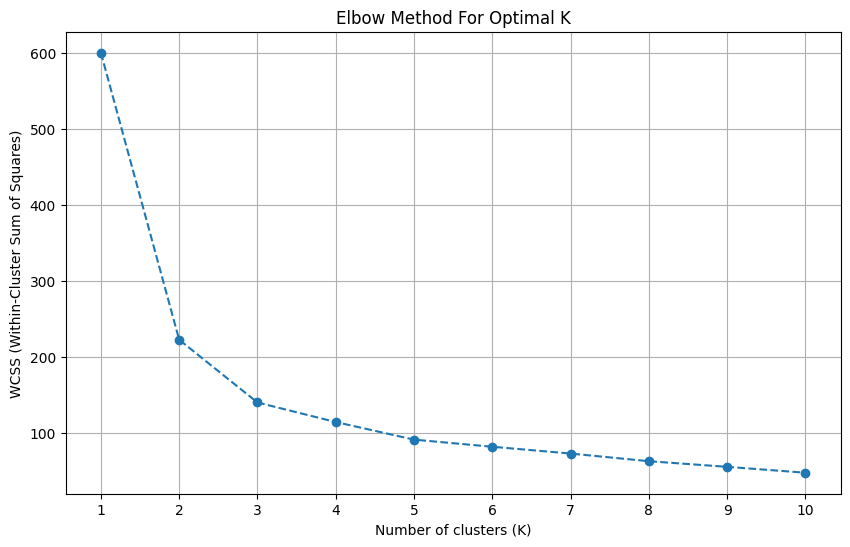

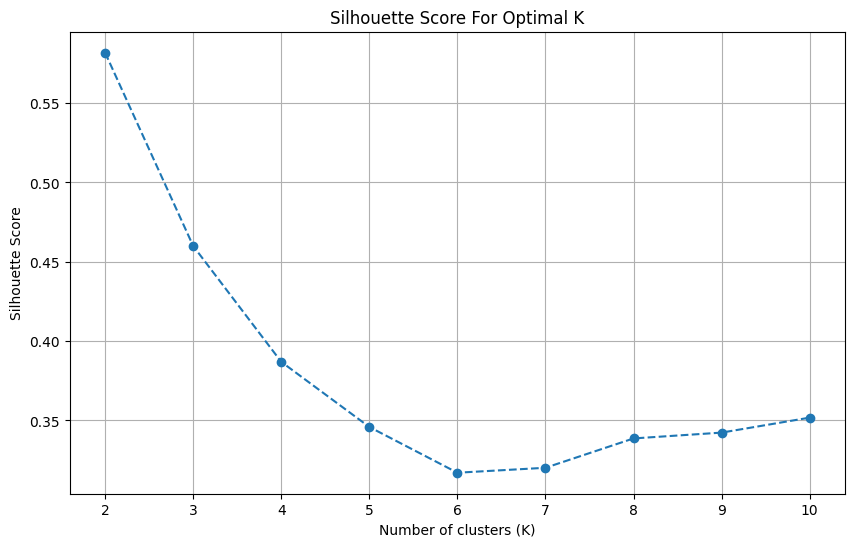

WCSS values: [600.0, 222.36170496502302, 139.82049635974974, 114.09254690403094, 90.92751382392049, 81.54439095511782, 72.6311438266719, 62.540605695781245, 55.119492805290584, 47.39103517634709]
Silhouette scores (for K=2 to K=10): [np.float64(0.5817500491982808), np.float64(0.45994823920518635), np.float64(0.38694104154427816), np.float64(0.3459012795948778), np.float64(0.31707940193569023), np.float64(0.3201967939183684), np.float64(0.33869173894897225), np.float64(0.3423598384813203), np.float64(0.3517926760640288)]


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. Elbow Method to find optimal K ---
wcss = [] # Within-Cluster Sum of Squares
max_k = 10 # Let's try K from 1 to max_k

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

# --- 2. Silhouette Analysis to find optimal K ---
silhouette_scores = []

# Silhouette score requires at least 2 clusters
for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

print("WCSS values:", wcss)
print("Silhouette scores (for K=2 to K={}):".format(max_k), silhouette_scores)


In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target (species) - not used for unsupervised clustering but useful for evaluation later
feature_names = iris.feature_names

df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = iris.target_names[y]

print("Iris dataset loaded. First 5 rows:")
display(df_iris.head())

print("\nChecking for missing values:")
display(df_iris.isnull().sum())

# Preprocessing: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
print("\nFeatures scaled using StandardScaler. First 5 rows of scaled data:")
display(df_scaled.head())

Iris dataset loaded. First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Checking for missing values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0



Features scaled using StandardScaler. First 5 rows of scaled data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
